   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.8 MB/s eta 0:00:00
Name - Suyash Jagtap
prn - 2025004077 


Saving cartruck.jpeg to cartruck.jpeg
Uploaded file: cartruck.jpeg
14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Predicted Object: trailer_truck
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/cartruck.jpeg: 320x640 1 car, 1 motorcycle, 1 truck, 338.9ms
Speed: 10.3ms preprocess, 338.9ms inference, 50.7ms postprocess per image at shape (1, 3, 320, 640)
YOLO Detection Result:


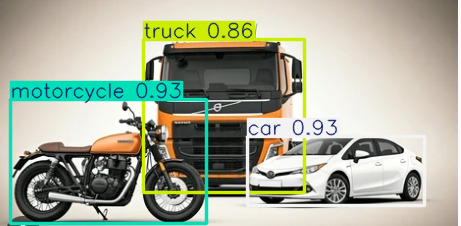

Segmented Image:


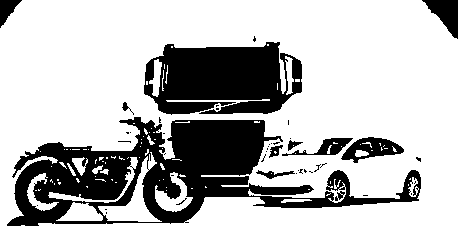

In [ ]:
# =======================
# INSTALL REQUIRED LIBRARY
# =======================
!pip install ultralytics -q
print("Name - Suyash Jagtap")
print("prn - 2025004077 ")
# =======================
# 1. UPLOAD IMAGE
# =======================-
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print("Uploaded file:", filename)

# =======================
# 2. OBJECT RECOGNITION (MobileNetV2)
# =======================
import numpy as np
import cv2
from tensorflow.keras.applications.mobilenet_v2 import (
    MobileNetV2,
    preprocess_input,
    decode_predictions
)

img = cv2.imread(filename)

if img is None:
    print("Error loading image")
else:
    model = MobileNetV2(weights='imagenet')

    img_resized = cv2.resize(img, (224, 224))
    img_array = np.expand_dims(img_resized, axis=0)
    img_array = preprocess_input(img_array)

    predictions = model.predict(img_array)
    label = decode_predictions(predictions)

    print("Predicted Object:", label[0][0][1])

# =======================
# 3. OBJECT DETECTION (YOLOv8)
# =======================
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

model = YOLO("yolov8n.pt")

results = model(filename)

print("YOLO Detection Result:")
results[0].show()

# =======================
# 4. IMAGE SEGMENTATION
# =======================
img = cv2.imread(filename)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#applying the threshold
_, segmented = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

print("Segmented Image:")
cv2_imshow(segmented)